# Aplicación a Pricing de Opciones (Black-Scholes)

El objetivo de este último notebook es traducir nuestra ventaja predictiva (el modelo XGBoost) en una ventaja financiera ("Edge").

En el mercado de opciones, la volatilidad es el único parámetro de la fórmula de Black-Scholes que no es directamente observable en el mercado (el precio actual, el strike, el tiempo y la tasa de interés sí lo son). Por lo tanto, operar opciones es, en esencia, operar volatilidad. Si nuestro modelo XGBoost proyecta una volatilidad del 15%, pero el mercado está valorando las opciones asumiendo una volatilidad implícita del 20%, el mercado te está ofreciendo opciones "caras" que podrías vender.

# 1. Importación y Carga de la Volatilidad Proyectada

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import yfinance as yf

# Configuración visual
plt.style.use('seaborn-v0_8-darkgrid')

# Cargar las predicciones de volatilidad (XGBoost)
print("Cargando predicciones del modelo XGBoost...")
df_vol = pd.read_csv('../data/processed/final_volatility_forecast.csv', index_col='Date', parse_dates=True)

# Cargar los precios del SPY para las mismas fechas
# Necesitamos el precio del activo subyacente (S) para la fórmula
start_date = df_vol.index[0]
end_date = df_vol.index[-1] + pd.Timedelta(days=1) # +1 día para incluir el final
spy_data = yf.download('SPY', start=start_date, end=end_date)

# APLANAR COLUMNAS: Si yfinance devuelve niveles extra (como el Ticker 'SPY' arriba), los quitamos
if isinstance(spy_data.columns, pd.MultiIndex):
    spy_data.columns = spy_data.columns.get_level_values(0)

# BUSCAR COLUMNA: Intentamos 'Adj Close', si no, usamos 'Close' (que a veces ya viene ajustado)
col_a_usar = 'Adj Close' if 'Adj Close' in spy_data.columns else 'Close'

# FILTRAR Y RENOMBRAR
spy_data = spy_data[[col_a_usar]].copy()
spy_data.rename(columns={col_a_usar: 'Spot_Price'}, inplace=True)

# Unimos los dataframes
df_pricing = pd.merge(df_vol, spy_data, left_index=True, right_index=True, how='inner')
print(df_pricing.head())

[*********************100%***********************]  1 of 1 completed

Cargando predicciones del modelo XGBoost...
              Target  Forecasted_Vol  Spot_Price
Date                                            
2024-03-28  0.099038        0.103508  510.642426
2024-04-01  0.099380        0.102767  509.754150
2024-04-02  0.098266        0.103883  506.513031
2024-04-03  0.098101        0.103005  507.069397
2024-04-04  0.101425        0.104413  500.880096


# 2. Implementación del Modelo Black-Scholes

Aquí codificamos la famosa ecuación.
Las fórmulas para una opción Call europea ($C$) y Put europea ($P$) son:
$$C = S_0 N(d_1) - K e^{-rT} N(d_2)$$
$$P = K e^{-rT} N(-d_2) - S_0 N(-d_1)$$
Donde:
$$d_1 = \frac{\ln(S_0/K) + (r + \sigma^2/2)T}{\sigma\sqrt{T}}$$
$$d_2 = d_1 - \sigma\sqrt{T}$$

In [8]:
# Definición de la función de Black-Scholes
def black_scholes(S, K, T, r, sigma, option_type='call'):
    """
    Calcula el precio teórico de una opción europea.
    S: Precio Spot del subyacente
    K: Precio Strike
    T: Tiempo hasta expiración (en años)
    r: Tasa libre de riesgo (anualizada)
    sigma: Volatilidad (anualizada)
    option_type: 'call' o 'put'
    """
    # Si estamos exactamente en la expiración, el precio es el valor intrínseco
    if T <= 0:
        if option_type == 'call':
            return max(0.0, S - K)
        else:
            return max(0.0, K - S)
            
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    if option_type == 'call':
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == 'put':
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    else:
        raise ValueError("El tipo de opción debe ser 'call' o 'put'.")
        
    return price

# 3. Simulación de Estrategia de Pricing (Encontrando Discrepancias)

Como no tenemos una base de datos histórica de opciones, vamos a realizar un ejercicio cuantitativo muy común: calcularemos el "Precio Justo" (Fair Value) según nuestro modelo XGBoost y lo compararemos con un precio calculado usando una volatilidad tradicional y simplista (como la volatilidad histórica de los últimos 30 días) que usaremos como "Proxy del Mercado".

In [ ]:
# Parámetros de la simulación
# Asumiremos una tasa libre de riesgo constante (ej. 4% anual = 0.04)
RISK_FREE_RATE = 0.04
# Simularemos opciones At-The-Money (ATM) a 30 días
DAYS_TO_EXPIRY = 30
TIME_TO_EXPIRY_YEARS = DAYS_TO_EXPIRY / 252 

# Calculamos una volatilidad histórica ingenua de 30 días para actuar como "Implied Volatility del Mercado"
df_pricing['Hist_Vol_30d'] = np.log(df_pricing['Spot_Price'] / df_pricing['Spot_Price'].shift(1)).rolling(30).std() * np.sqrt(252)
df_pricing.dropna(inplace=True)

# Calculando precios
precios_xgb_call = []
precios_mercado_call = []

for index, row in df_pricing.iterrows():
    S = row['Spot_Price']
    K = S # Opciones ATM (Strike = Precio Actual)
    vol_xgb = row['Forecasted_Vol']
    vol_mercado = row['Hist_Vol_30d']
    
    # Precio "Justo" según el modelo predictivo (XGBoost)
    precio_justo = black_scholes(S, K, TIME_TO_EXPIRY_YEARS, RISK_FREE_RATE, vol_xgb, 'call')
    # Precio asumiendo que el mercado cotiza usando volatilidad pasada
    precio_mercado = black_scholes(S, K, TIME_TO_EXPIRY_YEARS, RISK_FREE_RATE, vol_mercado, 'call')
    
    precios_xgb_call.append(precio_justo)
    precios_mercado_call.append(precio_mercado)

df_pricing['Call_Price_XGBoost'] = precios_xgb_call
df_pricing['Call_Price_Market'] = precios_mercado_call

# Evaluando la discrepancia (Mispricing)
# Porcentaje de diferencia entre lo que dice el mercado y lo que dice nuestro modelo
df_pricing['Mispricing_Pct'] = (df_pricing['Call_Price_Market'] - df_pricing['Call_Price_XGBoost']) / df_pricing['Call_Price_XGBoost'] * 100

# 4. Visualización del "Edge" y Señales de Trading

Finalmente, visualizamos los resultados. \
El siguiente gráfico traduce nuestra ventaja predictiva (Machine Learning) en señales de trading accionables.

Si el "Precio de Mercado" es mucho mayor que el "Precio XGBoost", significa que la opción está sobrevalorada según nuestro modelo (señal de VENTA). Si es menor, está infravalorada (señal de COMPRA).

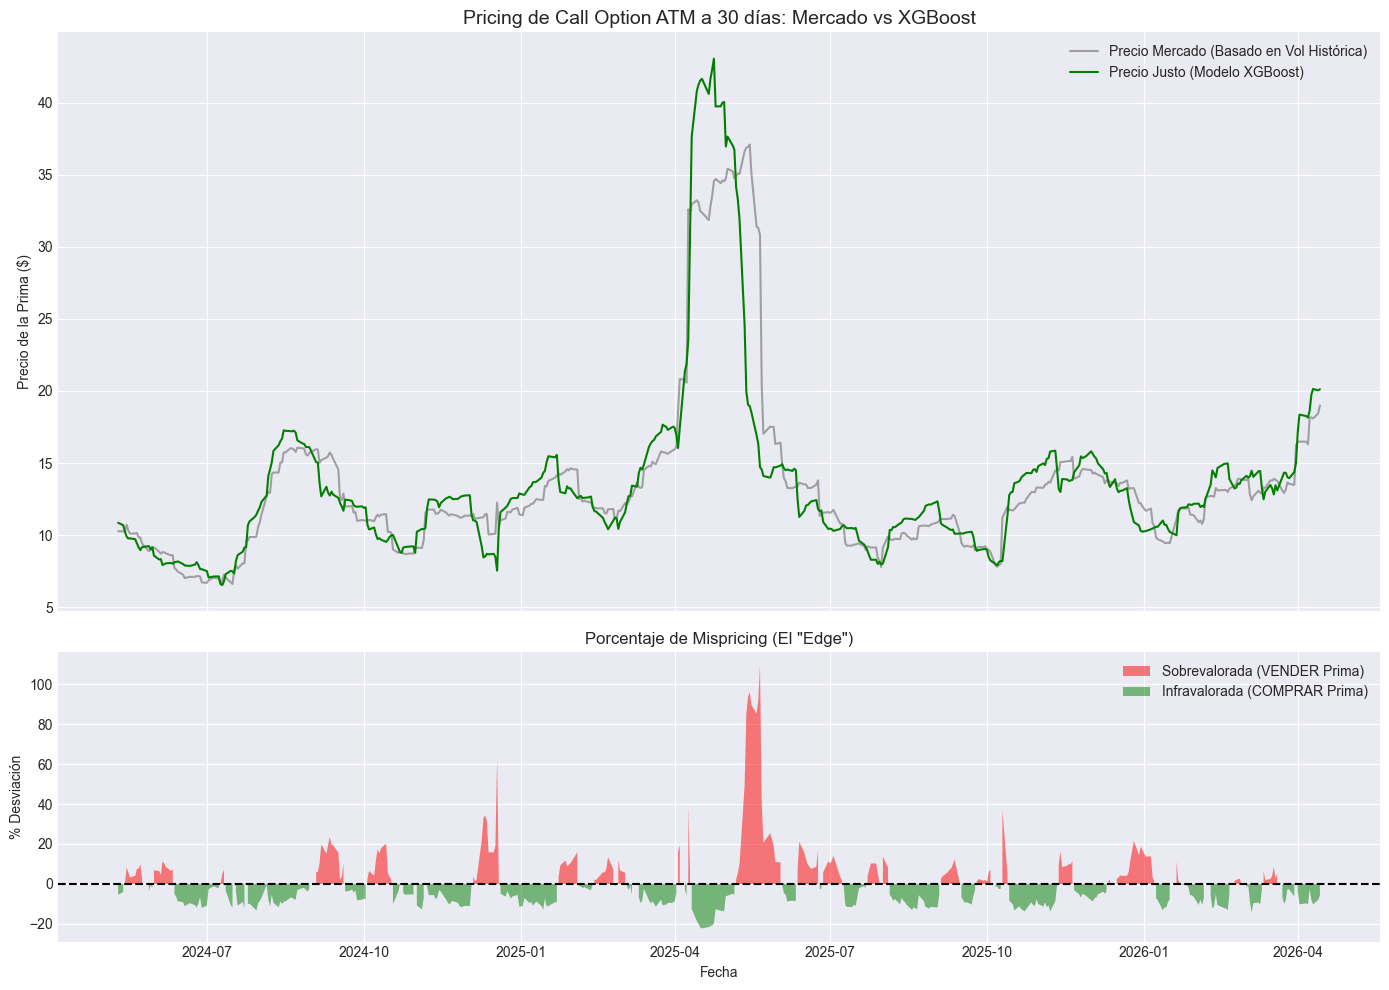

Total de días analizados: 482
Oportunidades Claras de COMPRA (Mercado barato según XGBoost): 219 días
Oportunidades Claras de VENTA (Mercado caro según XGBoost): 125 días


In [10]:
# Visualización de Resultados
fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]}, sharex=True)

# Subplot 1: Comparativa de Precios de la Opción Call
axes[0].plot(df_pricing.index, df_pricing['Call_Price_Market'], label='Precio Mercado (Basado en Vol Histórica)', color='gray', alpha=0.7)
# Cambiamos la etiqueta a XGBoost y el color a verde para mantener consistencia
axes[0].plot(df_pricing.index, df_pricing['Call_Price_XGBoost'], label='Precio Justo (Modelo XGBoost)', color='green', linewidth=1.5)
axes[0].set_title('Pricing de Call Option ATM a 30 días: Mercado vs XGBoost', fontsize=14)
axes[0].set_ylabel('Precio de la Prima ($)')
axes[0].legend()

# Subplot 2: El Mispricing (Señal de Trading)
axes[1].fill_between(df_pricing.index, 0, df_pricing['Mispricing_Pct'], 
                     where=(df_pricing['Mispricing_Pct'] > 0), facecolor='red', alpha=0.5, label='Sobrevalorada (VENDER Prima)')
axes[1].fill_between(df_pricing.index, 0, df_pricing['Mispricing_Pct'], 
                     where=(df_pricing['Mispricing_Pct'] < 0), facecolor='green', alpha=0.5, label='Infravalorada (COMPRAR Prima)')
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title('Porcentaje de Mispricing (El "Edge")')
axes[1].set_ylabel('% Desviación')
axes[1].set_xlabel('Fecha')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

# Estadísticas finales
dias_compra = len(df_pricing[df_pricing['Mispricing_Pct'] < -5]) # Más de un 5% infravalorada
dias_venta = len(df_pricing[df_pricing['Mispricing_Pct'] > 5])   # Más de un 5% sobrevalorada

print(f"Total de días analizados: {len(df_pricing)}")
print(f"Oportunidades Claras de COMPRA (Mercado barato según XGBoost): {dias_compra} días")
print(f"Oportunidades Claras de VENTA (Mercado caro según XGBoost): {dias_venta} días")